In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
image = cv2.imread("images/document.jpg")

if image is None:
    print("image not loaded successfully")
else:
    print("ready to go !")

In [ ]:
print(image.shape)
print(type(image))
print(image.dtype)

In [ ]:
image_rgb = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

In [ ]:
gray = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
print(gray.shape)

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.show()

In [ ]:
blur = cv2.GaussianBlur(gray,(5,5),0)

In [ ]:

plt.subplot(1,2,1)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(blur, cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off")

plt.show()

In [ ]:
edges = cv2.Canny(blur, 75, 200)

In [ ]:
plt.figure(figsize=(8,6))
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")
plt.show()

In [ ]:
contours,hierarchy = cv2.findContours(edges,cv2.RETR_LIST,cv2.CHAIN_APPROX_SIMPLE)

In [ ]:
print(type(contours))
print(len(contours))
print(type(hierarchy))

In [ ]:
print(contours[0].shape)
print(contours[0])

In [ ]:
print(hierarchy.shape)

In [ ]:
contours = sorted(contours,key=cv2.contourArea,reverse=True)
print(contours[0])
print(contours[1])
print(contours[2])

In [ ]:
largest_contour_image = image.copy()

cv2.drawContours(
    largest_contour_image,
    [contours[0]],
    -1,
    (0, 255, 0),
    3
)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(largest_contour_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [ ]:
perimeter = cv2.arcLength(contours[0],True)
perimeter

In [ ]:
approx = cv2.approxPolyDP(
    contours[0],
    0.02 * perimeter,
    True
)
approx

In [ ]:
approx_image = image.copy()

cv2.drawContours(
    approx_image,
    [approx],
    -1,
    (0, 255, 0),
    5
)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(approx_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [ ]:
pts = approx.reshape(4,2)
s = pts.sum(axis=1)

top_left = pts[np.argmin(s)]
bottom_right = pts[np.argmax(s)]

diff = np.diff(pts, axis=1)

top_right = pts[np.argmin(diff)]
bottom_left = pts[np.argmax(diff)]

In [38]:
rect = np.zeros((4,2), dtype="float32")

rect[0] = pts[np.argmin(s)]      # Top-Left
rect[2] = pts[np.argmax(s)]      # Bottom-Right
rect[1] = pts[np.argmin(diff)]   # Top-Right
rect[3] = pts[np.argmax(diff)]   # Bottom-Left

print(rect)

[[ 29. 229.]
 [571. 150.]
 [728. 860.]
 [132. 986.]]


In [41]:
(topLeft, topRight, bottomRight, bottomLeft) = rect

widthA = np.linalg.norm(bottomRight - bottomLeft)
widthB = np.linalg.norm(topRight - topLeft)

maxWidth = max(int(widthA), int(widthB))

heightA = np.linalg.norm(topRight - bottomRight)
heightB = np.linalg.norm(topLeft - bottomLeft)

maxHeight = max(int(heightA), int(heightB))

In [43]:
print("max W",maxWidth)
print("max H",maxHeight)

max W 609
max H 763


In [44]:
dst = np.array([
    [0, 0],
    [maxWidth - 1, 0],
    [maxWidth - 1, maxHeight - 1],
    [0, maxHeight - 1]
], dtype="float32")

print(dst)

[[  0.   0.]
 [608.   0.]
 [608. 762.]
 [  0. 762.]]


In [45]:
M = cv2.getPerspectiveTransform(rect, dst)

print(M)
print(M.shape)

[[ 1.08771224e+00 -1.47997835e-01  2.34784915e+00]
 [ 1.66234281e-01  1.14049342e+00 -2.65993787e+02]
 [-6.31398283e-05  1.66140277e-04  1.00000000e+00]]
(3, 3)


In [46]:
warped = cv2.warpPerspective(
    image,
    M,
    (maxWidth, maxHeight)
)

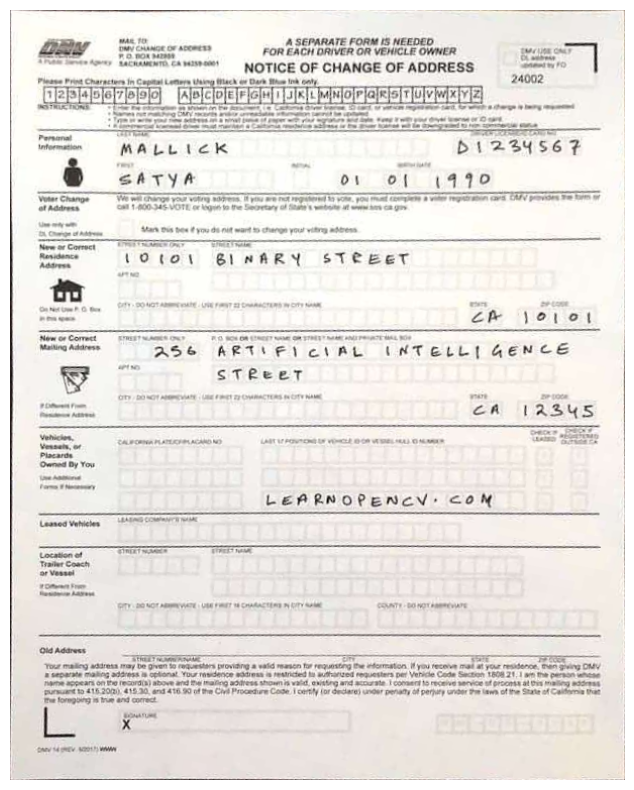

In [47]:
plt.figure(figsize=(8, 10))
plt.imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()